In [1]:
from flask import Flask, render_template, request, jsonify
import os
from werkzeug.utils import secure_filename
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
app_name=Flask(__name__)
folder_path='Models'
app_name.config['UPLOAD_FOLDER']=folder_path
# model_path= folder_path + '/ft_model.keras'
# print(model_path)
# model=tf.keras.models.load_model(model_path)

In [3]:
extension={'jpg','jpeg','png','gif'}
def allowed_file(filename):
    return '.' in filename and filename.rsplit('.',1)[1].lower() in extension

In [4]:
@app_name.route('/')
def first_page():
    return render_template('index_demo.html',result=None)

In [5]:
@app_name.route('/<a>')
def ava(a):
    flash('{}coming soon',format(a))
    return render_template('index_demo.html',result=None,scroll='third')

In [6]:
@app_name.route('/assessment',methods=['GET','POST'])
def assess():
    return render_template('index_demo.html',result=None,scroll='third')

In [7]:
# from re import I
# def recounstracring_img(img_path):
#   image=Image.open(img_path).convert('RGB')
#   image=image.resize(256,256,3) #the value of the resize is to be same as the input value of the model
#   image=np.array(image)
#   image=image/255.0
#   image=np.expand_dims(image,axis=0)
#   return image

In [8]:
# @app_name.route('/assessment',methods=['GET','POST'])
# def predict():
#   if 'file' not in request.files:
#     return jsonify({'error':'file is not uploaded'})
#   file=request.files['file']
#   if file.filename=='':
#     return jsonify({'error':'no file selected'})
#   if file and allowed_file(file.filename):
#     filename=secure_filename(file.filename)
#     file_path=os.path.join(app_name.config['UPLOAD_FOLDER'],filename)
#     file.save(file_path)
#     converted_image=recounstracring_img(file_path)
#     prediction=model.predict(converted_image)
#     print(prediction)
#     damage_class=np.argmax(prediction)
#     print(damage_class)
#     return jsonify({'damage_class':damage_class})
#   else:
#     return jsonify({'error':'invalid file format'})

In [9]:
# Function to preprocess the image
def recounstracring_img(img_path):
    # Open the image and convert it to RGB format
    image = Image.open(img_path).convert('RGB')
    # Resize the image to the required input size of the model (e.g., 256x256)
    image = image.resize((256, 256))
    # Convert the image to a numpy array
    image = np.array(image)
    # Normalize the image by dividing by 255.0
    image = image / 255.0
    # Add a batch dimension
    image = np.expand_dims(image, axis=0)
    return image

In [ ]:
def predict(model):
    if 'file' not in request.files:
        return jsonify({'error': 'file is not uploaded'})
    
    file = request.files['file']
    if file.filename == '':
        return jsonify({'error': 'no file selected'})
    
    if file and allowed_file(file.filename):
        filename = secure_filename(file.filename)
        file_path = os.path.join(app_name.config['UPLOAD_FOLDER'], filename)
        file.save(file_path)
        
        # Load and preprocess the image
        # file_path = 'Phase 4/demo.jpeg'  # Specify the correct image path

        # Load the model (ensure the path is correct)
        # model_path = 'Phase 4/ft_model.keras'
        # model = tf.keras.models.load_model(model_path)

        converted_image = recounstracring_img(file_path)

        # Make the prediction
        prediction = model.predict(converted_image)
        print("Prediction:", prediction)

        # Determine the predicted class
        damage_class = np.argmax(prediction)
        print("Predicted Class:", damage_class)

        # Display the image and prediction
        # Remove the batch dimension to display the image
        image_array_display = np.squeeze(converted_image)

        # Plot the image
        plt.imshow(image_array_display)
        plt.title(f"Predicted Class: {damage_class}")
        plt.axis('off')  # Hide the axis
        plt.show()
        
        return render_template('results.html', result=prediction, scroll='third', filename=filename)
    else:
        return jsonify({'error': 'invalid file format'})

In [13]:
# List of model filenames
# Load all models
models = []
model_prefix = 'ft_model_'
model_extension = '.keras'
model_index = 0
for model_index in range(1 + 1, 4 + 1):
    model_path = os.path.join(folder_path, model_prefix + str(model_index) + model_extension)
    model = tf.keras.models.load_model(model_path)
    print(f'Model Loaded: { model_path }')
    models.append(model)
    model_index += 1

Model Loaded: Models\ft_model_2.keras
Model Loaded: Models\ft_model_3.keras
Model Loaded: Models\ft_model_4.keras


In [14]:
# Function to get predictions from all models
def get_predictions():
    predictions = []
    for model in models:
        prediction = predict(model)
        # prediction = model.predict(input_data)
        predictions.append(prediction)
    return predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
Prediction: [[0.00122535]]
Predicted Class: 0


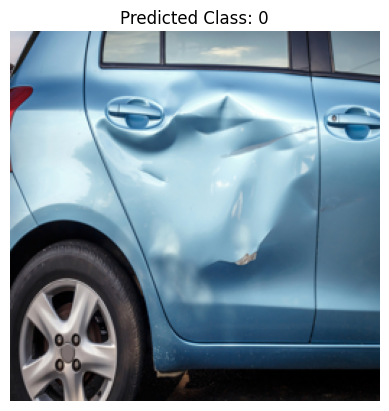

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Prediction: [[0.07553113 0.08813117 0.8363376 ]]
Predicted Class: 2


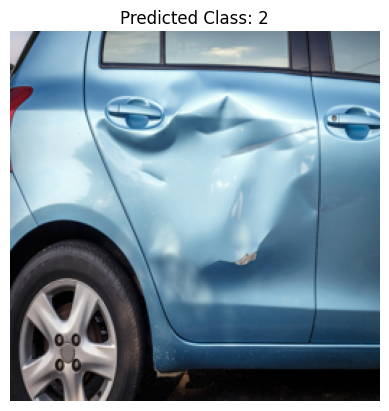

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Prediction: [[0.65357286 0.3238107  0.02261646]]
Predicted Class: 0


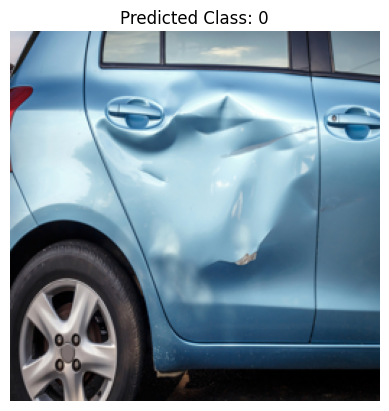

[None, None, None]


In [ ]:
# def predict(model):
#     file_path = 'Phase 4/demo.jpeg'  # Specify the correct image path

#     # Load the model (ensure the path is correct)
#     # model_path = 'Phase 4/ft_model.keras'
#     # model = tf.keras.models.load_model(model_path)

#     converted_image = recounstracring_img(file_path)

#     # Make the prediction
#     prediction = model.predict(converted_image)
#     print("Prediction:", prediction)

#     # Determine the predicted class
#     damage_class = np.argmax(prediction)
#     print("Predicted Class:", damage_class)

#     # Display the image and prediction
#     # Remove the batch dimension to display the image
#     image_array_display = np.squeeze(converted_image)

#     # Plot the image
#     plt.imshow(image_array_display)
#     plt.title(f"Predicted Class: {damage_class}")
#     plt.axis('off')  # Hide the axis
#     plt.show()

# predictions = []
# for model in models:
#     prediction = predict(model)
#     # prediction = model.predict(input_data)
#     predictions.append(prediction)

# print(predictions)

In [13]:
# from PIL import Image
# import numpy as np
# import tensorflow as tf

# # Function to preprocess the image
# def recounstracring_img(img_path):
#     # Open the image and convert it to RGB format
#     image = Image.open(img_path).convert('RGB')
#     # Resize the image to the required input size of the model (e.g., 256x256)
#     image = image.resize((256, 256))
#     # Convert the image to a numpy array
#     image = np.array(image)
#     # Normalize the image by dividing by 255.0
#     image = image / 255.0
#     # Add a batch dimension
#     image = np.expand_dims(image, axis=0)
#     return image

# # Load and preprocess the image
# image_path = 'Phase 4/demo.jpeg'  # Specify the correct image path
# image_array = recounstracring_img(image_path)

# # Load the model (ensure the path is correct)
# model_path = 'Phase 4/ft_model.keras'
# model = tf.keras.models.load_model(model_path)

# # Make the prediction
# prediction = model.predict(image_array)
# print("Prediction:", prediction)

# # Determine the predicted class
# damage_class = np.argmax(prediction)
# print("Predicted Class:", damage_class)

# # Display the image and prediction
# # Remove the batch dimension to display the image
# image_array_display = np.squeeze(image_array)

# # Plot the image
# plt.imshow(image_array_display)
# plt.title(f"Predicted Class: {damage_class}")
# plt.axis('off')  # Hide the axis
# plt.show()

In [14]:
# import os

# @app_name.route('/download')
# def download_file():
#     filepath = 'path/to/your/file.ext'
#     if os.path.exists(filepath):
#         return send_file(filepath, as_attachment=True)
#     else:
#         return "File not found", 404

In [ ]:
if __name__ == '__main__':
	app_name.run(host='0.0.0.0', port=8080, debug=True, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8080
 * Running on http://192.168.2.137:8080
Press CTRL+C to quit
127.0.0.1 - - [03/Dec/2024 00:01:26] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [03/Dec/2024 00:01:26] "GET /static/splash2.jpg HTTP/1.1" 404 -
127.0.0.1 - - [03/Dec/2024 00:01:31] "GET /static/loading_image.gif HTTP/1.1" 404 -
127.0.0.1 - - [03/Dec/2024 00:01:31] "POST /assessment HTTP/1.1" 200 -
127.0.0.1 - - [03/Dec/2024 00:01:31] "GET /static/splash2.jpg HTTP/1.1" 404 -
